In [394]:
import os
import json
import csv
import h5py

from collections import defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [395]:
def lowest_tn(folder_path):
    lowest_energy = {}
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as file:
                reader = csv.DictReader(file, delimiter=';')
                for row in reader:
                    instance = row['instance'].split('_P')[0]
                    energy = float(row['energy'])
                    if instance in lowest_energy:
                        if energy < lowest_energy[instance]:
                            lowest_energy[instance] = energy
                    else:
                        lowest_energy[instance] = energy
    
    return lowest_energy

In [396]:
def all_energies_tn(folder_path):
    all_energies = {}
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as file:
                reader = csv.DictReader(file, delimiter=';')
                for row in reader:
                    instance = row['instance'].split('_P')[0]
                    energy = float(row['energy'])
                    
                    if instance in all_energies:
                        all_energies[instance].append(energy)
                    else:
                        all_energies[instance] = [energy]
    
    return all_energies

In [462]:
def all_energies_tn_beta(folder_path):
    all_energies = {}
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as file:
                reader = csv.DictReader(file, delimiter=';')
                for row in reader:
                    beta = float(row['β'])
                    energy = float(row['energy'])
                    
                    if beta in all_energies:
                        all_energies[beta].append(energy)
                    else:
                        all_energies[beta] = [energy]
    
    return all_energies

In [463]:
def lowest_dwave(csv_file):
    lowest_energy = {}
    
    with open(csv_file, 'r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            instance = row['instance'].split('.txt')[0]
            energy = float(row['dwave_energy'])
            
            if instance in lowest_energy:
                if energy < lowest_energy[instance]:
                    lowest_energy[instance] = energy
            else:
                lowest_energy[instance] = energy
    
    return lowest_energy

In [464]:
def lowest_sbm(csv_file_sbm):
    lowest_energy = {}
    
    with open(csv_file_sbm, 'r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            instance = row['instance'].split('_P')[0]
            energy = float(row['sbm_energy'])
            
            if instance in lowest_energy:
                if energy < lowest_energy[instance]:
                    lowest_energy[instance] = energy
            else:
                lowest_energy[instance] = energy
    
    return lowest_energy

In [465]:
def find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv):
    data_tn = lowest_tn(instances_tn)
    data_dw = lowest_dwave(instances_dw)
    data_sbm = lowest_sbm(instances_sbm)
    lowest_energy = {} 
    
    all_instances_data = {}
    all_keys = set(data_tn.keys()).union(data_dw.keys(), data_sbm.keys())

    for key in all_keys:
        values_list = [data_tn.get(key, None), data_dw.get(key, None), data_sbm.get(key, None)]
        all_instances_data[key] = [value for value in values_list if value is not None]
    for instance, energy in all_instances_data.items():
        if instance in data_tn.keys():
            lowest_energy[instance] = min(energy)

    data_list = [[instance, energy] for instance, energy in lowest_energy.items()]
    df = pd.DataFrame(data_list, columns=["Instance", "Energy"])
    df_sorted = df.sort_values(by="Instance")
    df_sorted.to_csv(output_csv, index=False)
    
    return lowest_energy, data_tn, data_sbm, data_dw

In [466]:

# def plot_instance_energy(instances_tn, instances_dw, instances_sbm, output_csv):
#     lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv)
    
#     sorted_lowest_energy = dict(sorted(lowest_energy.items()))
#     sorted_data_tn = dict(sorted(data_tn.items()))
#     sorted_data_sbm = dict(sorted(data_sbm.items()))
#     sorted_data_dw = dict(sorted(data_dw.items()))

#     all_instances = sorted(set(sorted_lowest_energy.keys()) | set(sorted_data_tn.keys()) | set(sorted_data_sbm.keys()) | set(sorted_data_dw.keys()))

#     energies_best = [sorted_lowest_energy.get(instance, None) for instance in all_instances]
#     energies_tn = [sorted_data_tn.get(instance, None) for instance in all_instances]
#     energies_sbm = [sorted_data_sbm.get(instance, None) for instance in all_instances]
#     energies_dwave = [sorted_data_dw.get(instance, None) for instance in all_instances]

#     energies_best = ['None' if energy is None else energy for energy in energies_best]
#     energies_tn = ['None' if energy is None else energy for energy in energies_tn]
#     energies_sbm = ['None' if energy is None else energy for energy in energies_sbm]
#     energies_dwave = ['None' if energy is None else energy for energy in energies_dwave]

    # df = pd.DataFrame({
    #     "Instance": [f"{i+1:03d}" for i in range(len(all_instances))],  # Numeracja instancji
    #     # "Best Energy": energies_best,      # Najlepsza energia
    #     "TN": energies_tn,      # Energia TN12
    #     "SBM": energies_sbm,        # Energia SBM
    #     "D-Wave": energies_dwave    # Energia D-Wave
    # })

    # df.to_csv(output_csv, index=False)


In [467]:
def plot_instance_energy(instances_tn, instances_dw, instances_sbm, output_csv):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv)
    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))

    all_instances = sorted(set(sorted_lowest_energy.keys()) | set(sorted_data_tn.keys()) | set(sorted_data_sbm.keys()) | set(sorted_data_dw.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(sorted_data_tn.get(instance, None))
    
    fig, axes = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes[idx]
        ax.plot(data['instances'], data['energies_tn'], marker='o', linestyle='-')
        ax.set_title(f'p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('Energy')
        ax.grid(True)
    
    plt.show()

In [468]:
def plot_instance_energy_all(instances_tn, instances_dw, instances_sbm, output_csv, topology, L):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv)
    
    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))
    all_instances = sorted(set(sorted_data_tn.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': [], 'energies_dw': [], 'energies_sbm': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            E_best = sorted_lowest_energy.get(instance, 1)  # Uniknięcie dzielenia przez zero
            
            norm_tn = (sorted_data_tn.get(instance, E_best) - E_best) / (2 * abs(E_best))
            norm_dw = (sorted_data_dw.get(instance, E_best) - E_best) / (2 * abs(E_best))
            norm_sbm = (sorted_data_sbm.get(instance, E_best) - E_best) / (2 * abs(E_best))
            if abs(norm_tn) < 1e-4:
                norm_tn = 1e-5
            if abs(norm_dw) < 1e-4:
                norm_dw = 1e-5
            if abs(norm_sbm) < 1e-4:
                norm_sbm = 1e-5
            
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(norm_tn)
            p2_groups[p2_value]['energies_dw'].append(norm_dw)
            p2_groups[p2_value]['energies_sbm'].append(norm_sbm)
    
    fig, axes = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True)
    axes = axes.flatten()
    
    colors = {'TN': 'blue', 'DWave': 'red', 'SBM': 'green'}
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes[idx]
        ax.plot(data['instances'], data['energies_dw'], marker='o', linestyle='-', color=colors['DWave'], label='DWave')
        ax.plot(data['instances'], data['energies_sbm'], marker='s', linestyle='--', color=colors['SBM'], label='SBM')
        ax.plot(data['instances'], data['energies_tn'], marker='^', linestyle='-.', color=colors['TN'], label='TN')

        ax.set_yscale('log')
        ax.set_ylim(9e-6, 1)
        ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
        ax.set_yticklabels(["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
        ax.set_title(f'{topology}, L = {L}, p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('(E - E_best) / 2|E_best|')
        ax.legend()
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.show()

In [469]:
def plot_instance_energy_all_tn(instances_tn, instances_dw, instances_sbm, output_csv, topology, L):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv)
    all_energies = all_energies_tn(instances_tn)
    sorted_all_energies = {k: sorted(v) for k, v in sorted(all_energies.items())}

    sorted_lowest_energy = dict(sorted(lowest_energy.items()))
    sorted_data_tn = dict(sorted(data_tn.items()))
    sorted_data_sbm = dict(sorted(data_sbm.items()))
    sorted_data_dw = dict(sorted(data_dw.items()))
    all_instances = sorted(set(sorted_data_tn.keys()))
    
    p2_groups = defaultdict(lambda: {'instances': [], 'energies_tn': [], 'energies_dw': [], 'energies_sbm': []})
    
    for instance in all_instances:
        parts = instance.split('_')
        if 'p2' in parts:
            p2_index = parts.index('p2') + 1
            p2_value = float(parts[p2_index])
            inst_name = '_'.join(parts[-2:])  # inst_1, inst_2, etc.
            E_best = sorted_lowest_energy.get(instance, 1)  # Uniknięcie dzielenia przez zero
            
            norm_energies = [(E - E_best) / (2 * abs(E_best)) for E in sorted_all_energies[instance]]
            norm_energies = [1e-5 if abs(e) < 1e-4 else e for e in norm_energies] 
           
            p2_groups[p2_value]['instances'].append(inst_name)
            p2_groups[p2_value]['energies_tn'].append(norm_energies)
    
    fig, axes = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, (p2, data) in enumerate(sorted(p2_groups.items())):
        ax = axes[idx]
        for i, inst in enumerate(data['instances']):
            ax.plot([inst] * len(data['energies_tn'][i]), data['energies_tn'][i], 'bo', alpha=0.7)
        
        ax.set_yscale('log')
        ax.set_ylim(9e-6, 1)
        ax.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
        ax.set_yticklabels(["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
        ax.set_title(f'{topology}, L = {L}, p2 = {p2}')
        ax.set_xlabel('Instance')
        ax.set_ylabel('(E - E_best) / 2|E_best|')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.show()

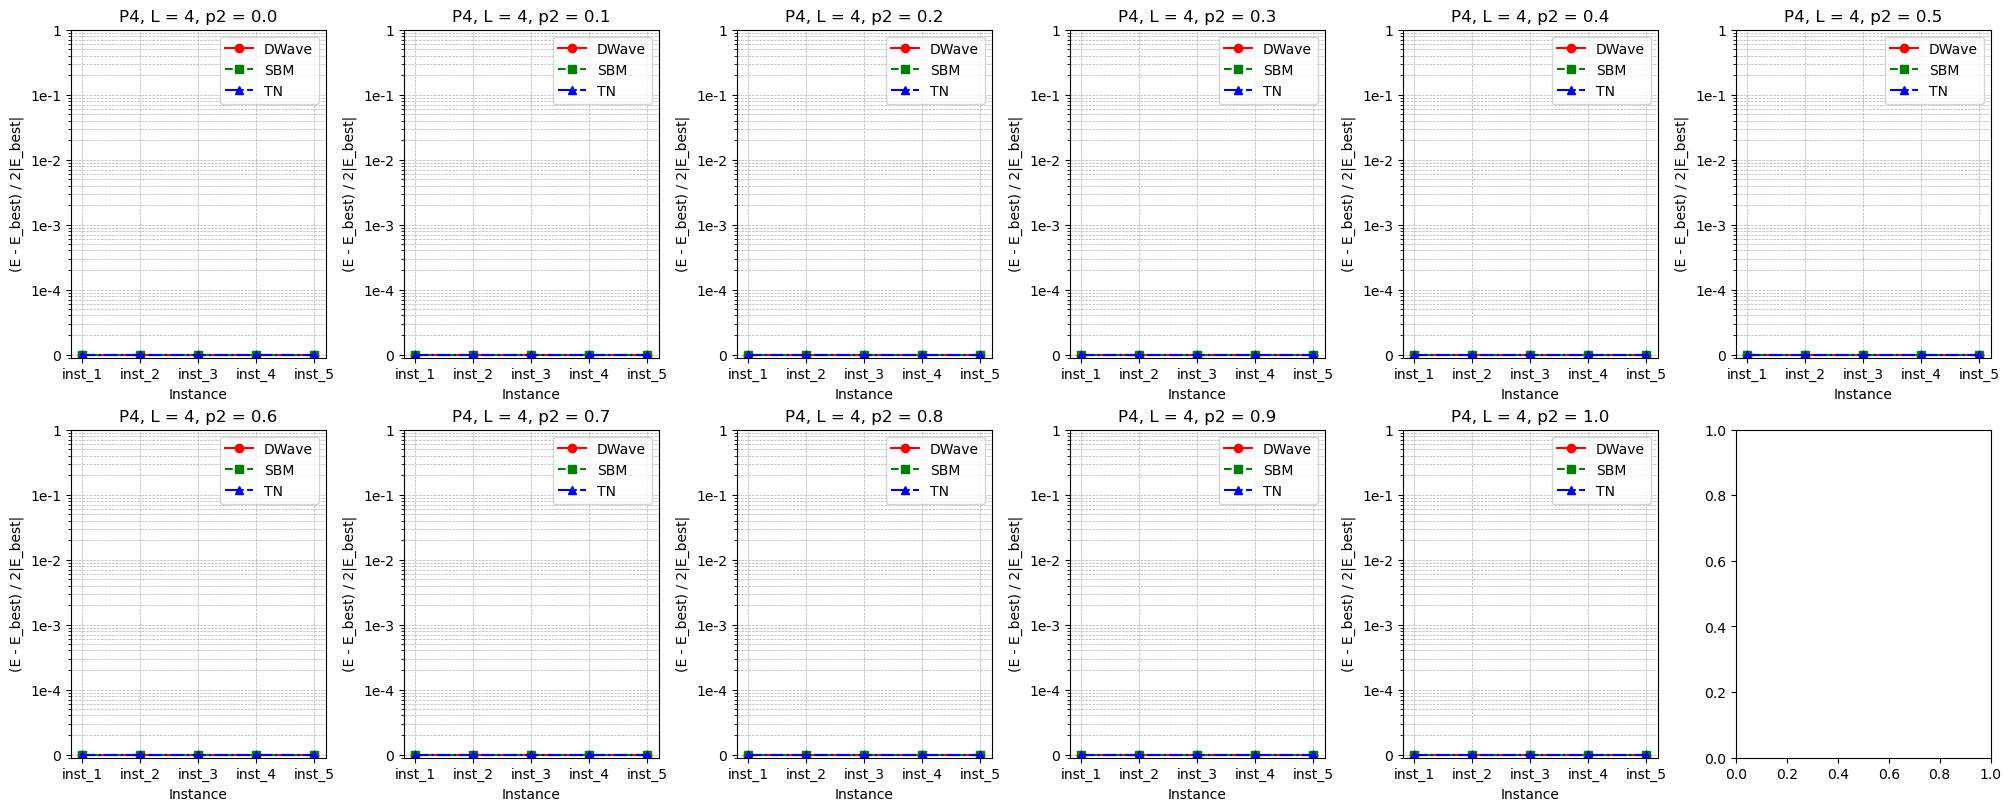

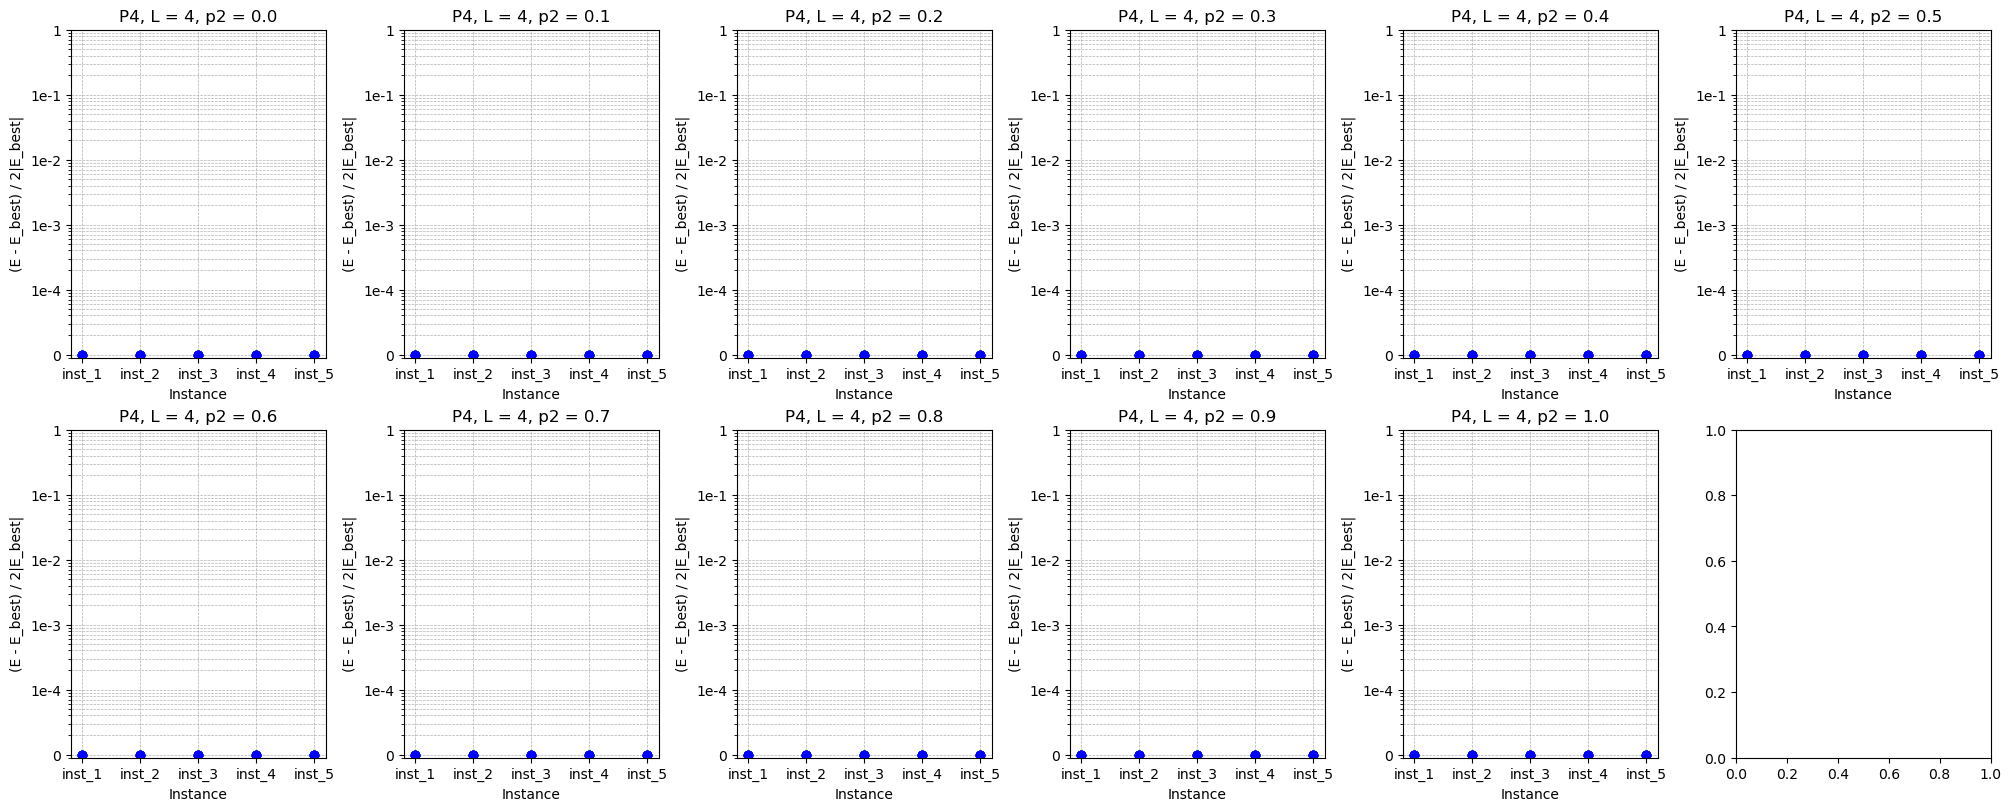

In [470]:
TOPOLOGY = "P4"
L = "4"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_2D_L_{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


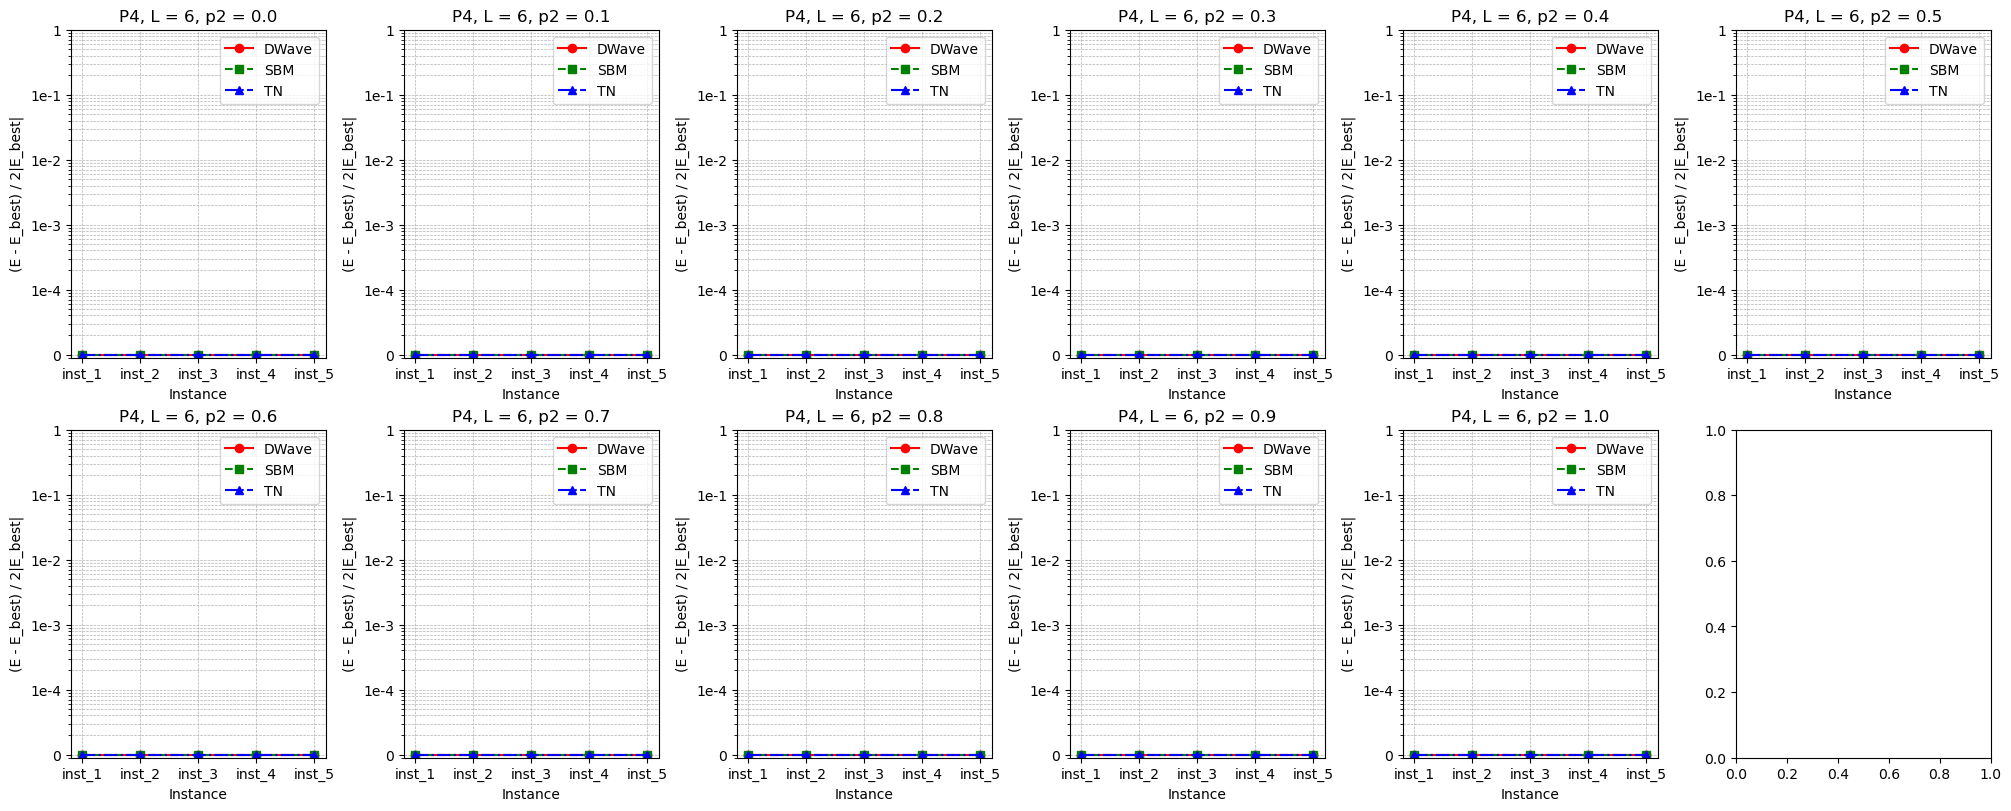

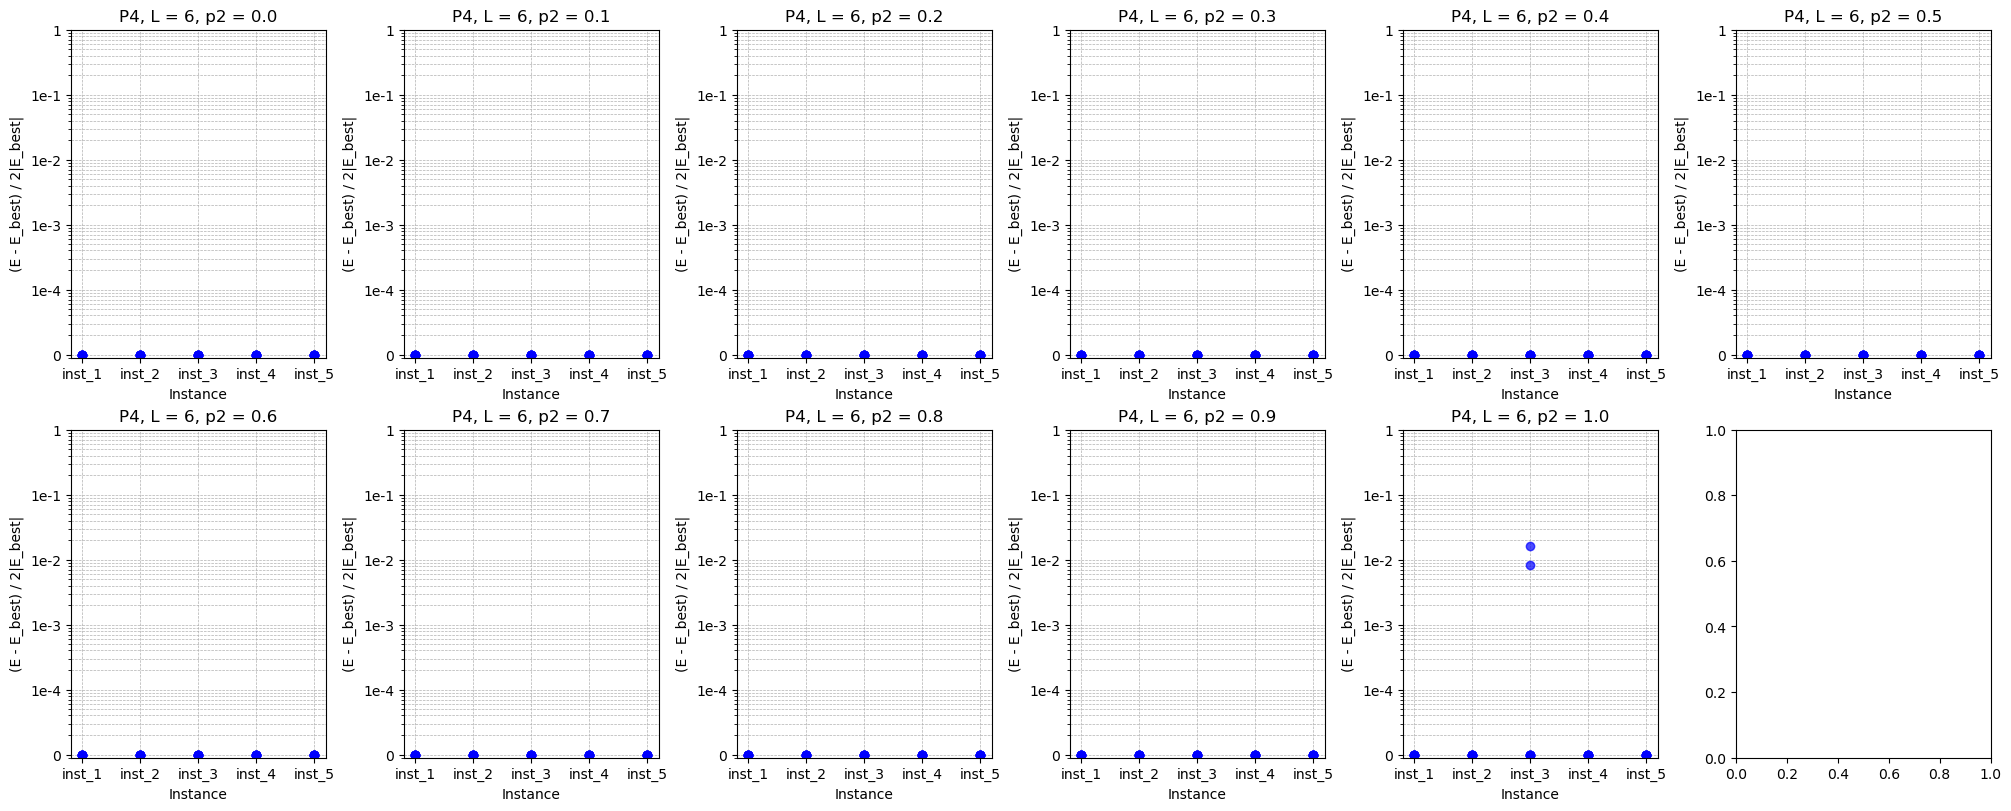

In [471]:
TOPOLOGY = "P4"
L = "6"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)

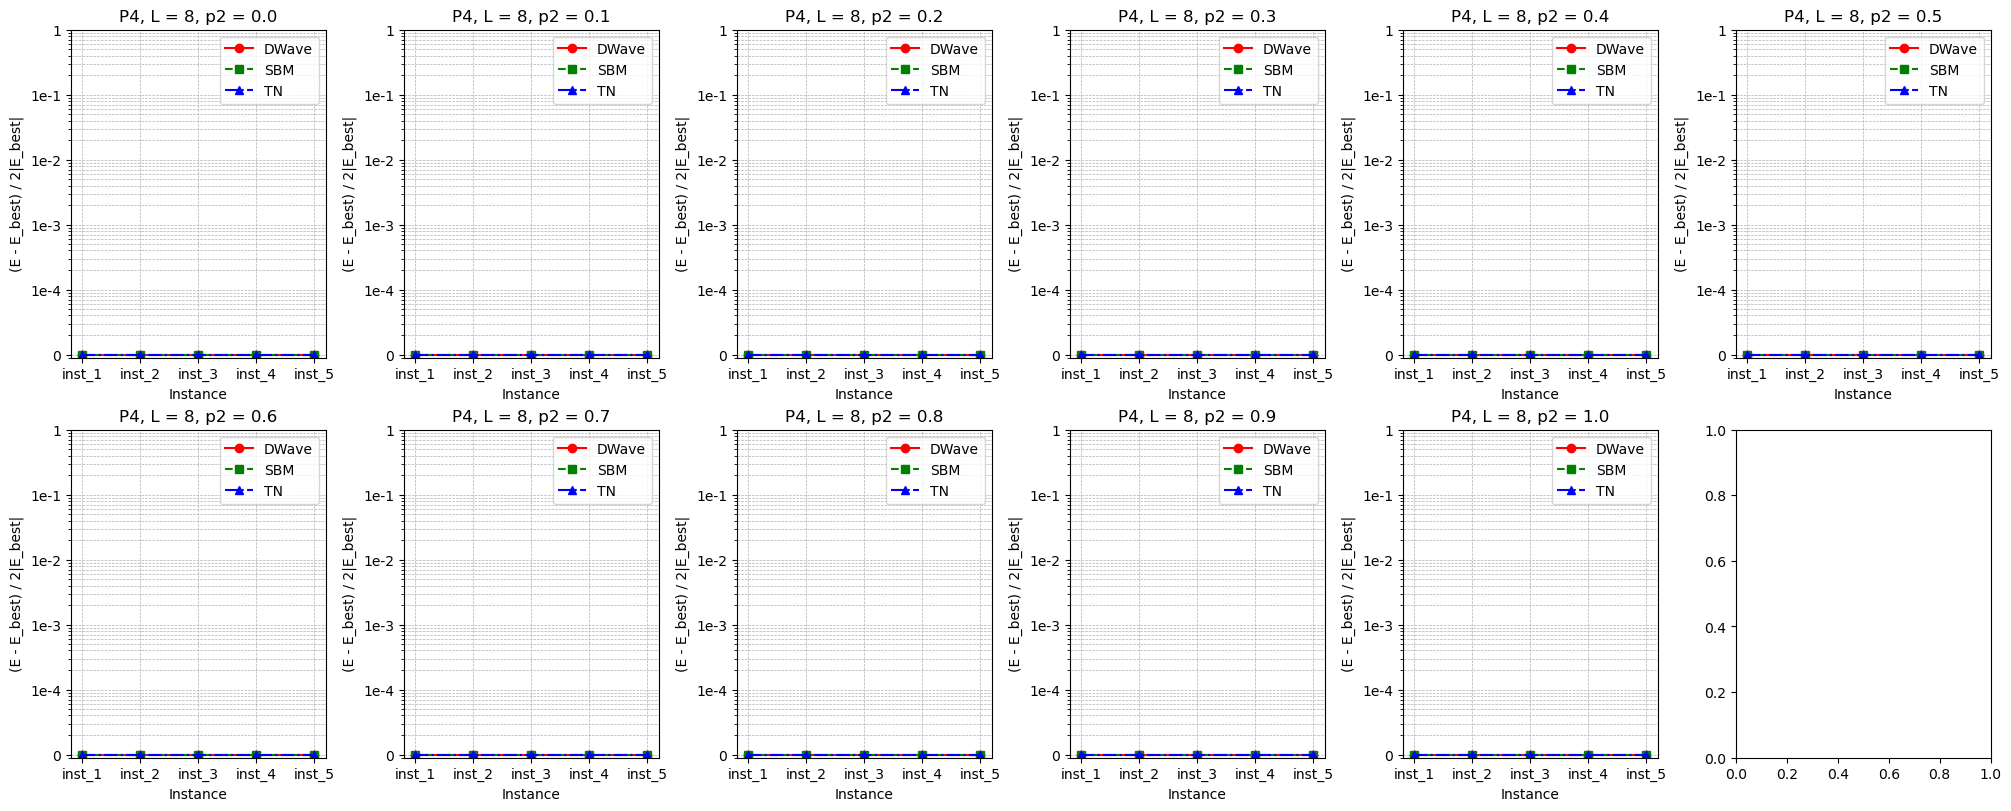

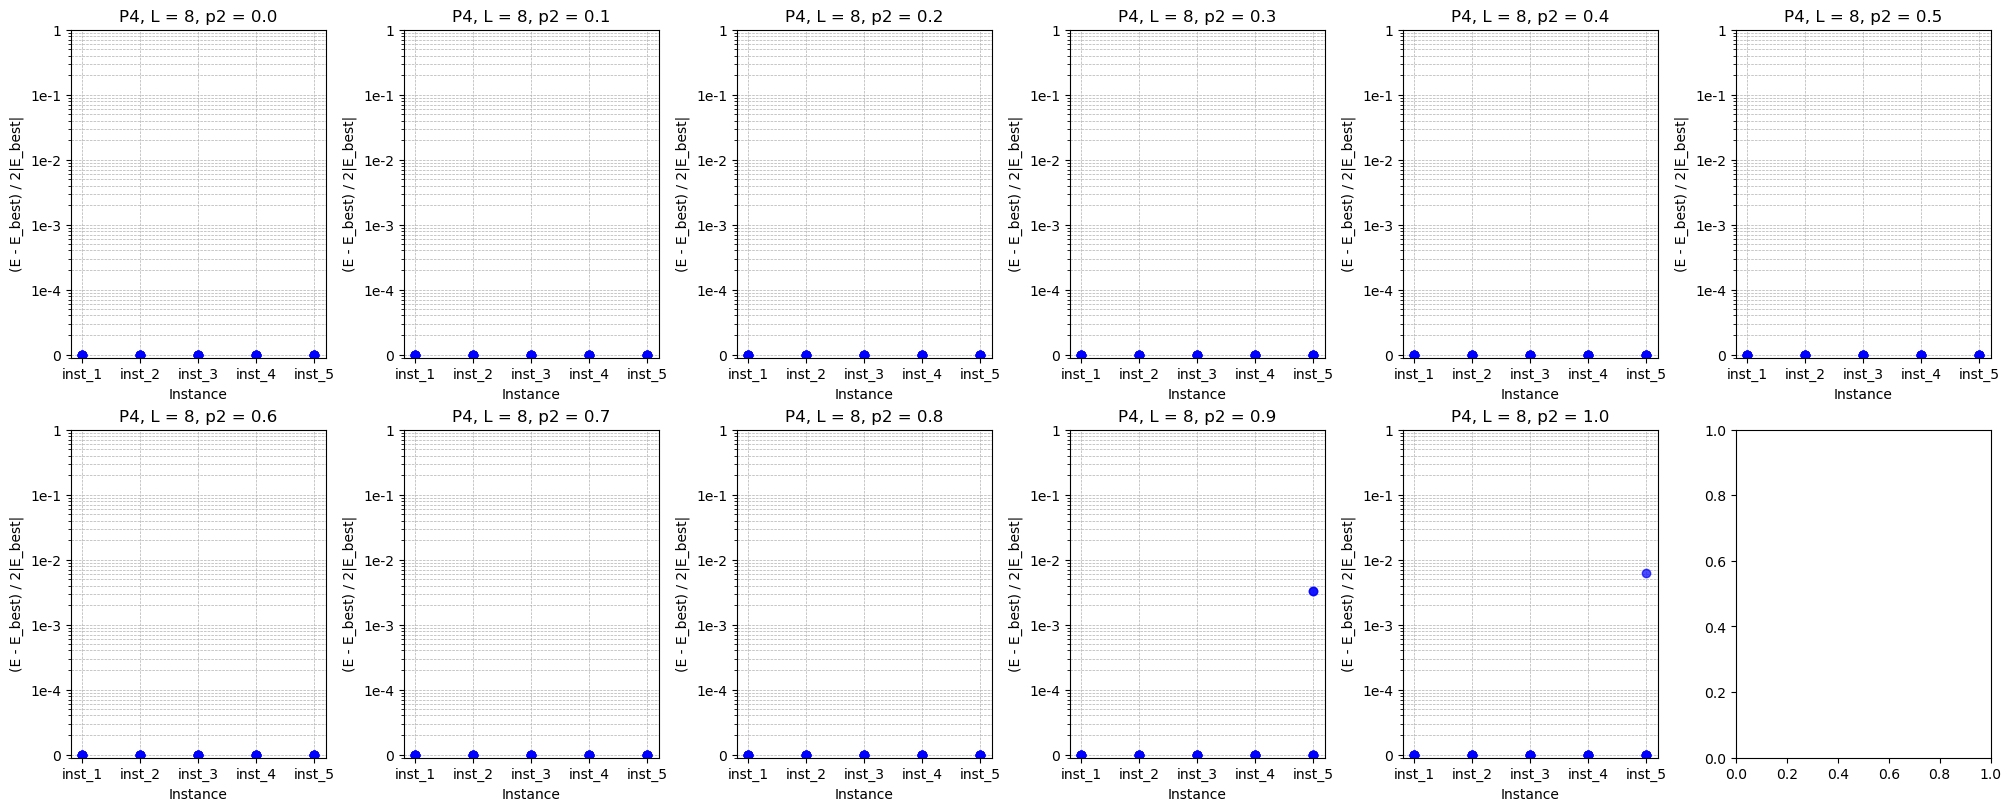

In [472]:
TOPOLOGY = "P4"
L = "8"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_2D_L_{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


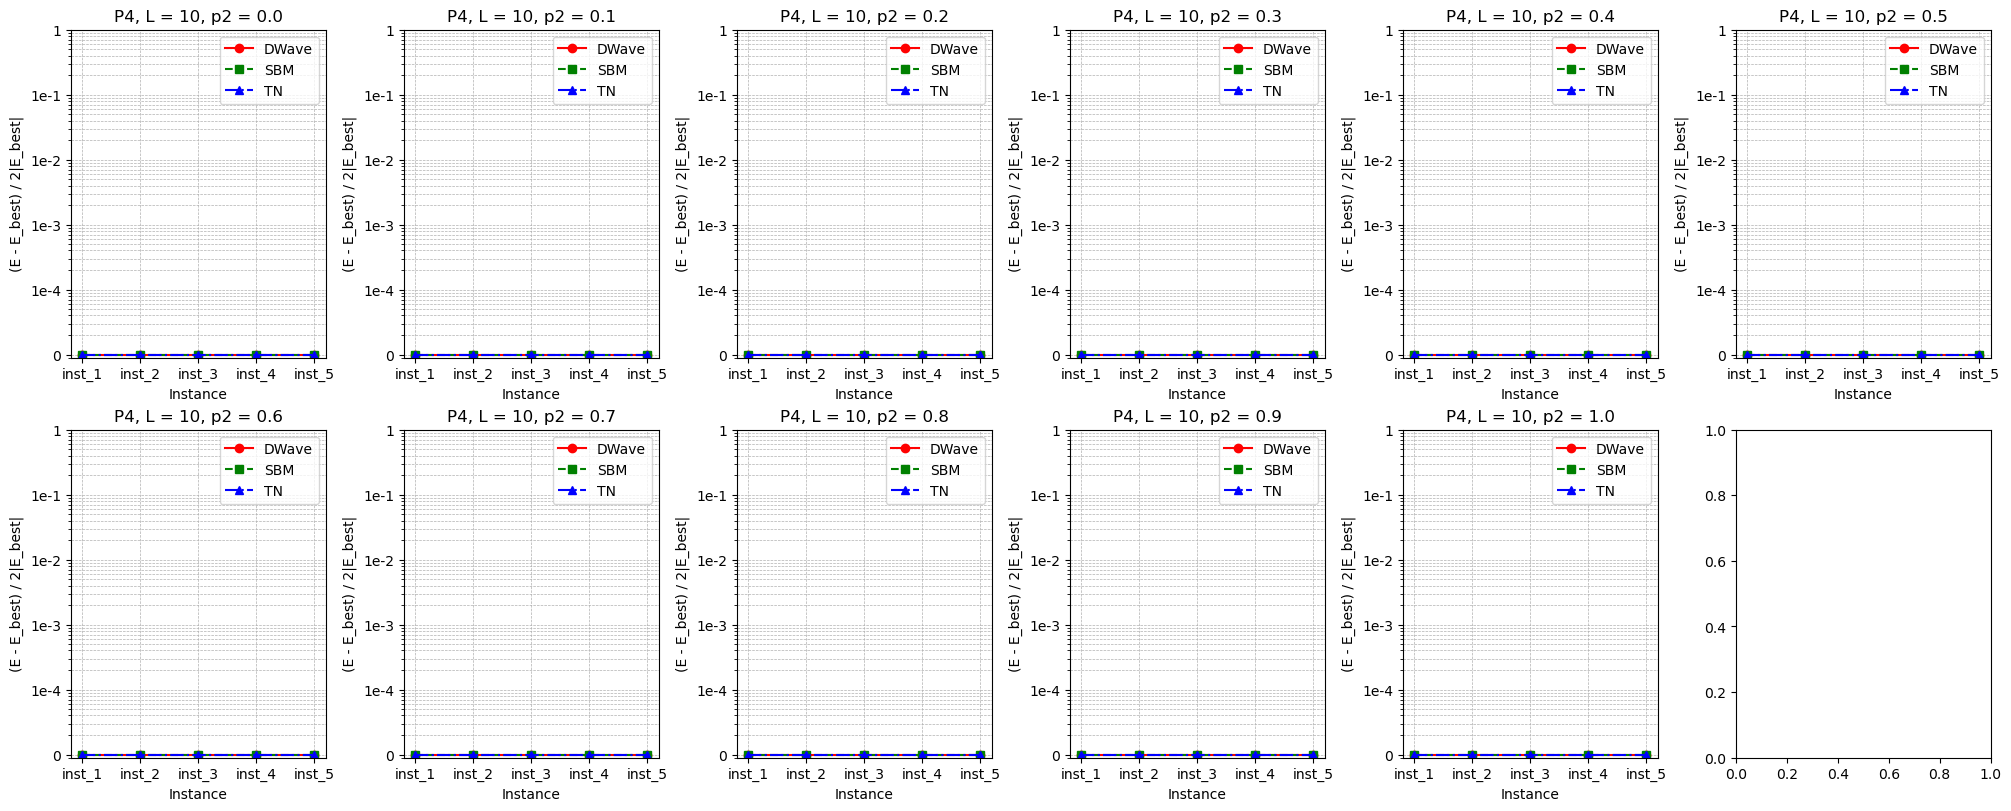

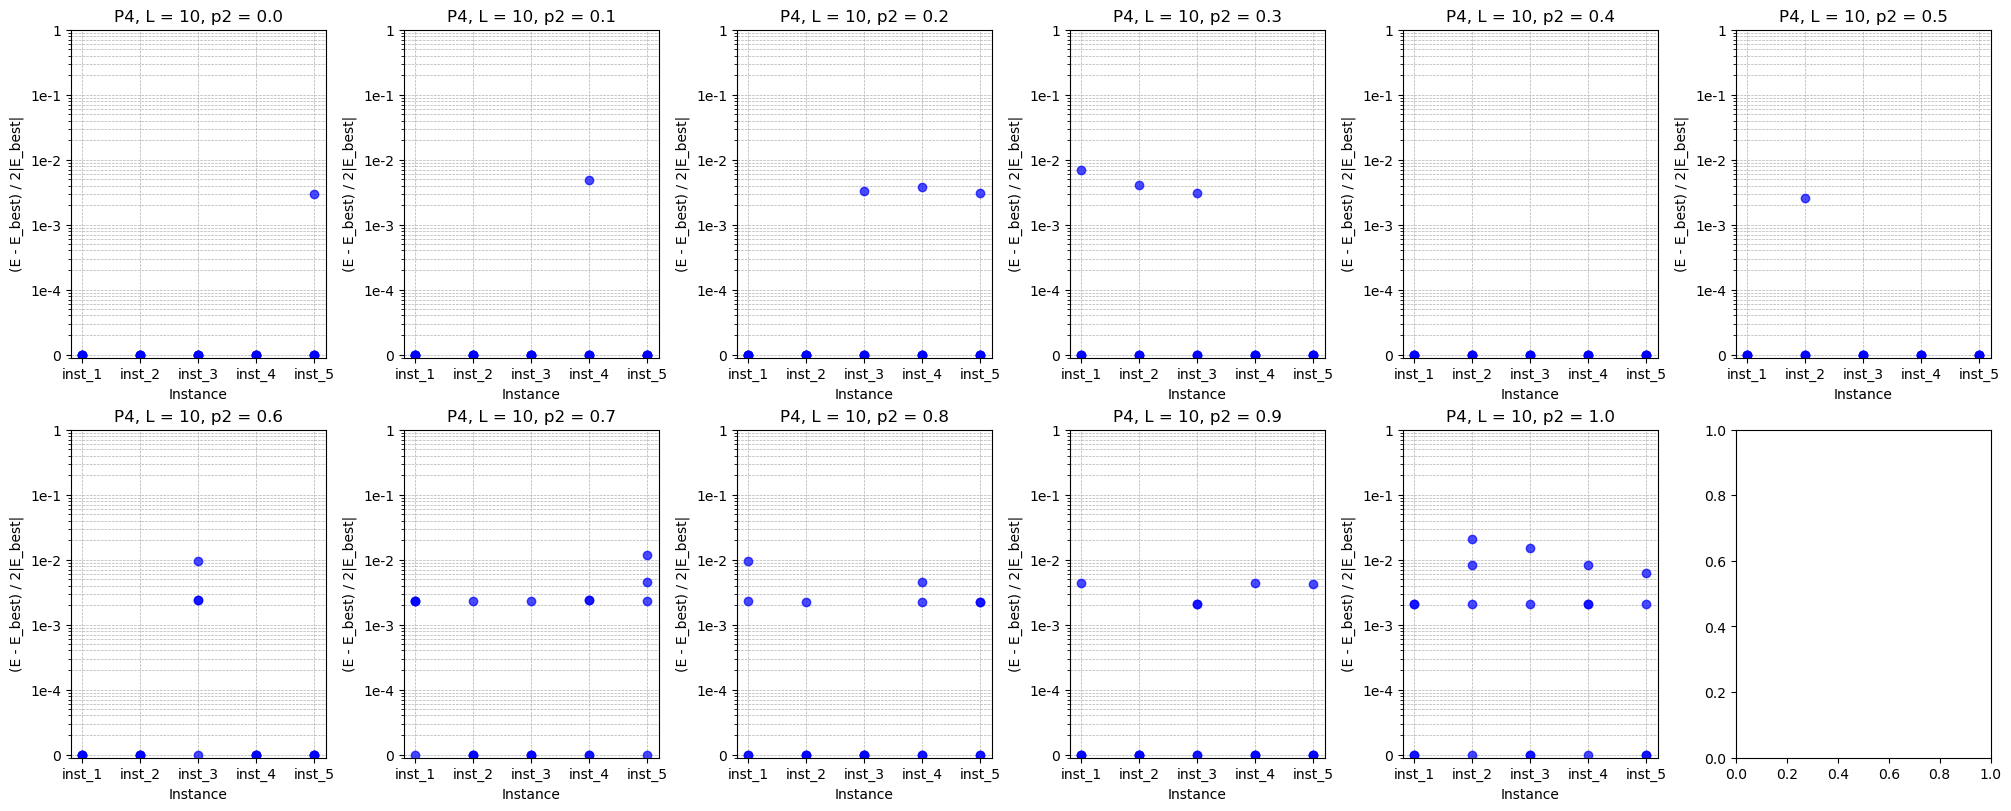

In [473]:
TOPOLOGY = "P4"
L = "10"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


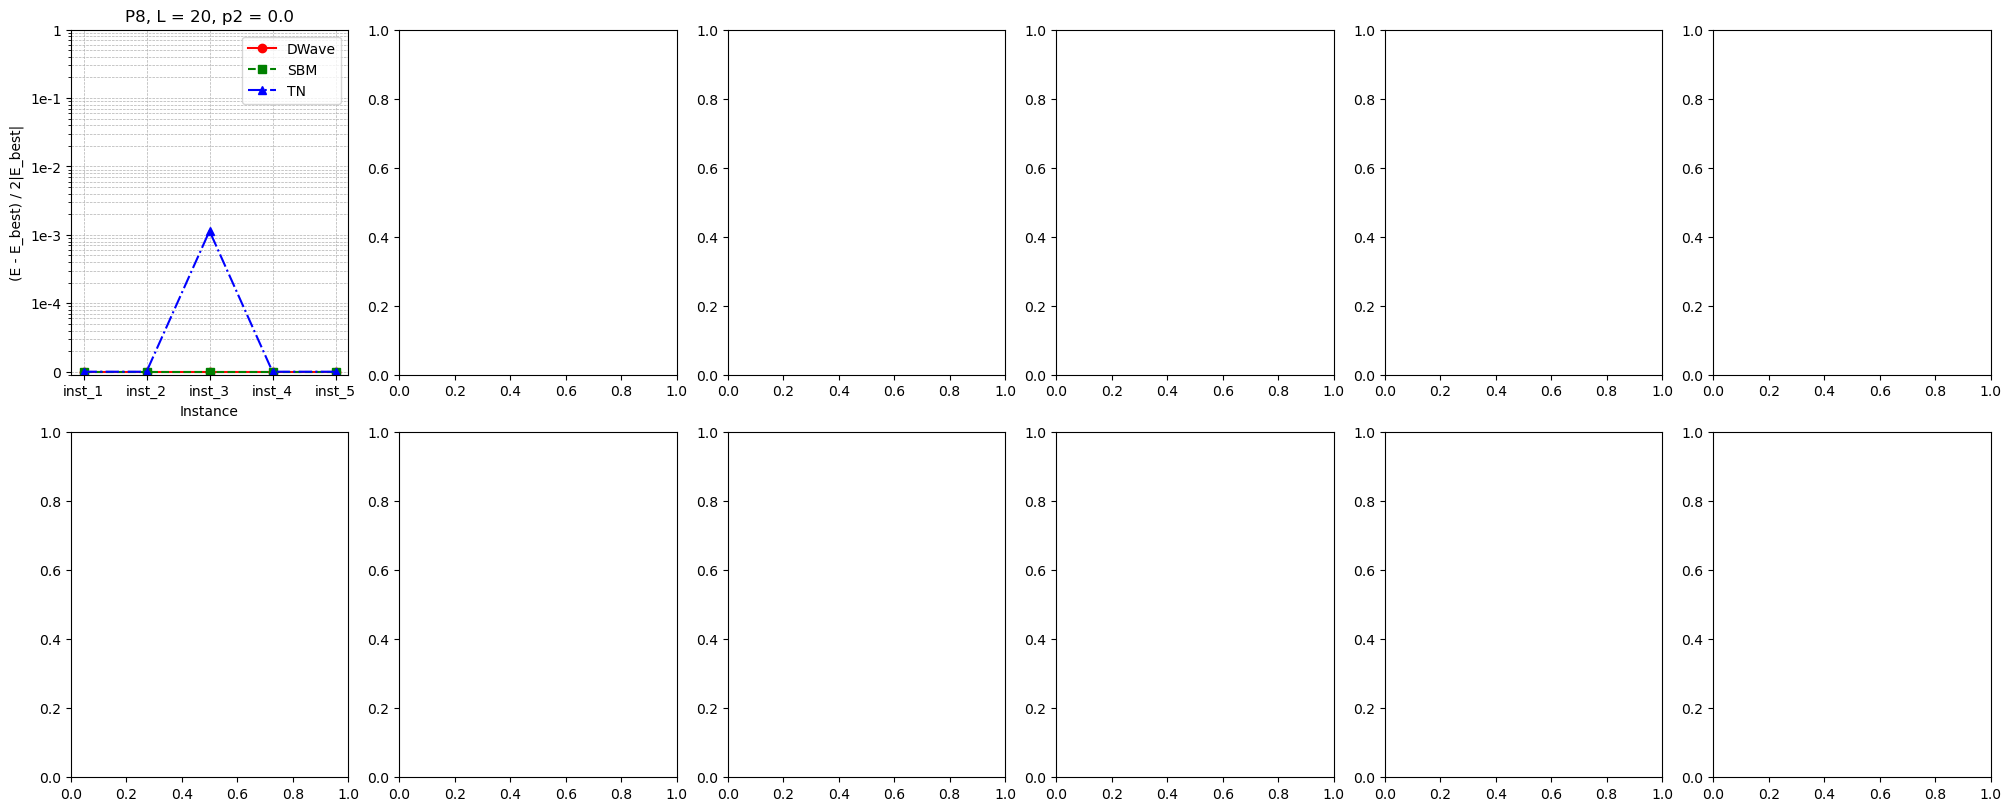

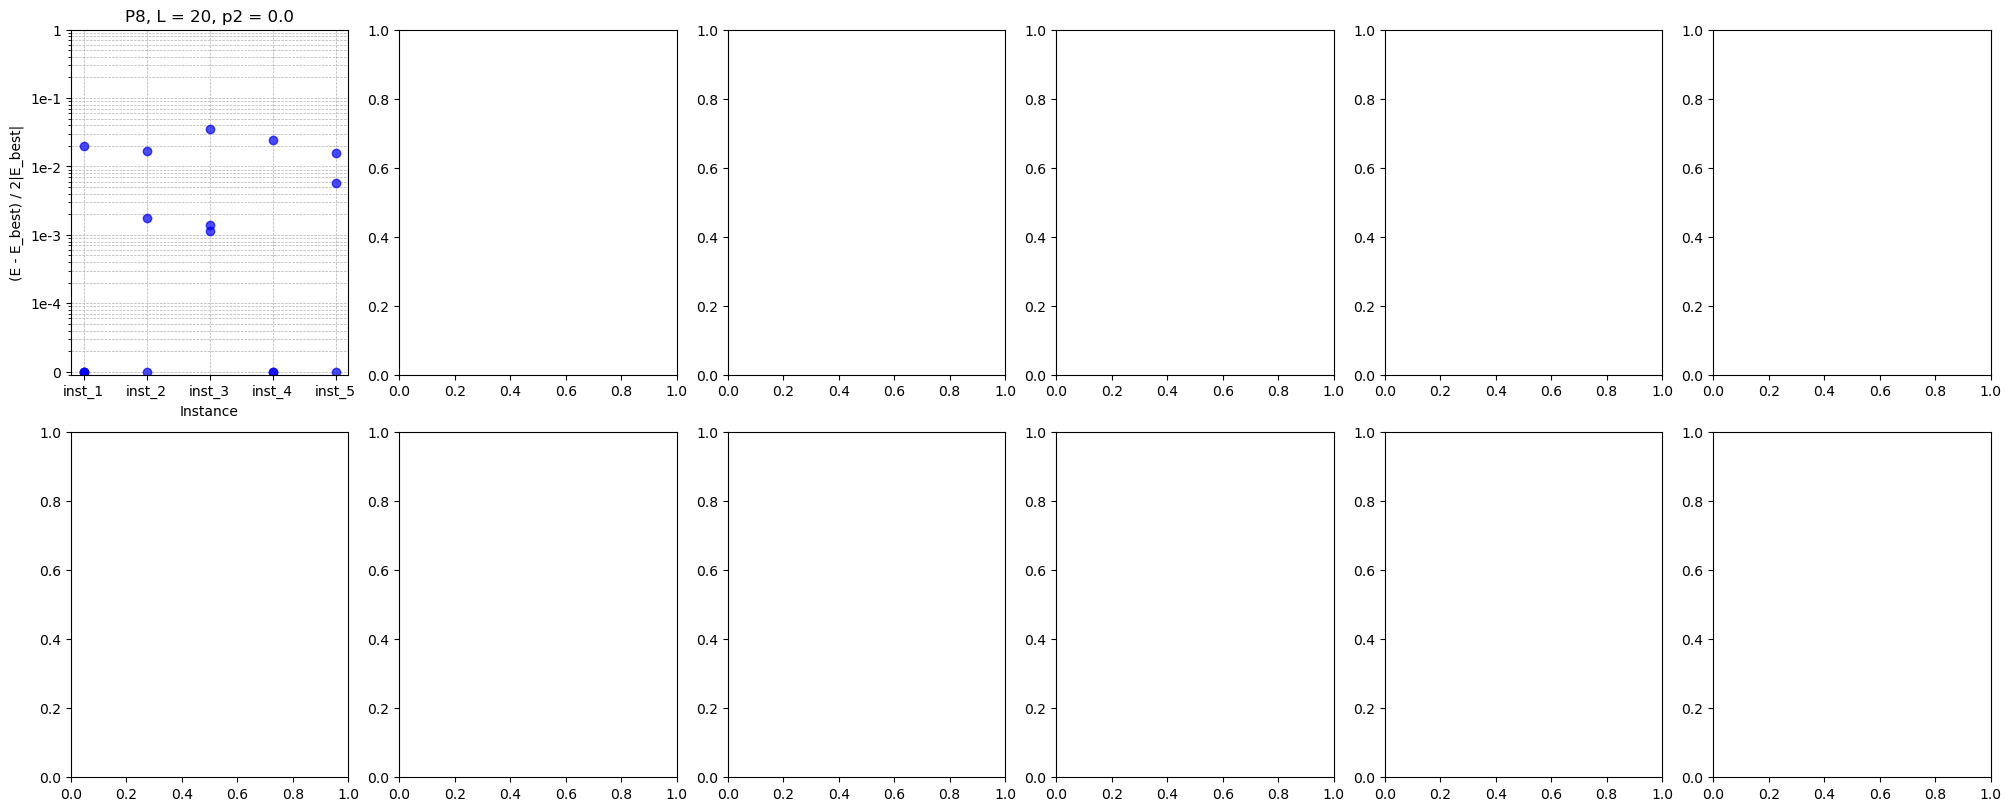

In [474]:
TOPOLOGY = "P8"
L = "20"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_2D_L_{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


In [475]:
import csv
import re
import ast

def parse_julia_dict(julia_dict_str):
    """Konwertuje słownik w formacie Julia do formatu Python."""
    julia_dict_str = julia_dict_str.strip()  # Usunięcie spacji i znaków nowej linii
    julia_dict_str = re.sub(r"Dict\((.*?)\)", r"{\1}", julia_dict_str)  # Zamiana Dict(...) na {...}
    julia_dict_str = re.sub(r"(\d+) *=> *(-?\d+)", r"\1: \2", julia_dict_str)  # Zamiana '56 => -1' na '56: -1'
    
    try:
        return ast.literal_eval(julia_dict_str)  # Parsowanie jako słownik Python
    except Exception as e:
        print(f"Błąd parsowania: {e}")
        print("Niepoprawne dane:", julia_dict_str)
        return None

def process_ig_states(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        first_row = next(reader)  # Pobranie pierwszego wiersza danych

        if "ig_states" not in first_row:
            print("Brak pola 'ig_states' w pliku.")
            return
        
        # Pobranie surowych danych ig_states
        ig_states_raw = first_row["ig_states"]

        # Sprawdzenie, czy dane są w formacie listy
        if ig_states_raw.startswith("[") and ig_states_raw.endswith("]"):
            # Usunięcie nawiasów listy, aby obsłużyć pojedynczy słownik
            ig_states_raw = ig_states_raw[1:-1].strip()

        # Konwersja do słownika Python
        ig_states = parse_julia_dict(ig_states_raw)

        if ig_states:
            keys = sorted(list(ig_states.keys()))
            print("Klucze w ig_states:", keys)
            print("Liczba kluczy:", len(keys))
        else:
            print("Nie udało się sparsować danych.")

def extract_unique_nodes(file_path):
    unique_nodes = set()

    # Otwieramy plik tekstowy
    with open(file_path, 'r') as file:
        for line in file:
            # Sprawdzamy czy wiersz nie jest pusty
            line = line.strip()
            if line:
                # Rozdzielamy wiersz na i, j i Jij
                i, j, Jij = line.split()

                # Przekształcamy na odpowiednie typy danych
                i, j, Jij = int(i), int(j), float(Jij)

                # Jeśli Jij jest różne od 0, dodajemy i i j do zbioru
                if Jij != 0:
                    unique_nodes.add(i)
                    unique_nodes.add(j)

    return unique_nodes

TOPOLOGY = "P4"
L = "10"
root = os.getcwd()
# tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}", "8205823051276761.csv")
instance = os.path.join(root, "instances", f"{TOPOLOGY}_adv6.4", f"tile_planting_2D_L_{L}_p1_0.0_p2_0.0_p3_0.0_inst_1_{TOPOLOGY}.txt")

# process_ig_states(tn_directory)
unique_nodes = extract_unique_nodes(instance)
print("Unikalne węzły:", unique_nodes)
print("Liczba unikalnych węzłów:", len(unique_nodes))

Unikalne węzły: {1, 6, 7, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 55, 58, 59, 60, 61, 62, 66, 67, 68, 70, 72, 73, 77, 79, 81, 82, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 136, 137, 138, 139, 140, 142, 144, 145, 149, 150, 151, 153, 154, 157, 158, 159, 160, 167, 168, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 181, 182, 183, 184, 185, 186, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 205, 206, 207, 208, 209, 211, 212, 214, 215, 216}
Liczba unikalnych węzłów: 164


In [476]:
TOPOLOGY = "P8"
L = "20"
root = os.getcwd()
# tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}", "8205823051276761.csv")
instance = os.path.join(root, "instances", f"{TOPOLOGY}_adv6.4", "tile_planting_2D_L_20_p1_0.0_p2_0.0_p3_0.0_inst_1_P8.txt")

# process_ig_states(tn_directory)
unique_nodes = extract_unique_nodes(instance)
print("Unikalne węzły:", unique_nodes)
print("Liczba unikalnych węzłów:", len(unique_nodes))

Unikalne węzły: {1, 2, 6, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 34, 35, 36, 37, 39, 40, 41, 42, 43, 45, 47, 48, 49, 50, 52, 53, 54, 61, 62, 63, 64, 66, 69, 71, 74, 75, 76, 78, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 106, 109, 110, 113, 114, 116, 117, 118, 119, 130, 134, 139, 140, 141, 142, 169, 170, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 192, 194, 195, 197, 198, 199, 201, 203, 204, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 226, 228, 229, 230, 232, 233, 234, 235, 238, 242, 245, 246, 247, 249, 251, 253, 254, 255, 256, 257, 258, 259, 261, 262, 264, 265, 268, 270, 271, 272, 273, 274, 275, 277, 278, 279, 280, 281, 283, 284, 285, 287, 288, 289, 290, 291, 294, 295, 297, 298, 302, 303, 304, 306, 307, 308, 309, 311, 314, 315, 324, 342, 345, 346, 347, 348, 349, 352, 353, 354, 355, 356, 361, 362, 363, 364, 365, 366, 367, 368, 370, 371, 372, 373, 374, 375, 

In [477]:
TOPOLOGY = "P16"
L = "40"
root = os.getcwd()
# tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}", "8205823051276761.csv")
instance = os.path.join(root, "instances", f"{TOPOLOGY}_adv6.4", "tile_planting_2D_L_40_p1_0.0_p2_0.0_p3_0.0_inst_1_P16.txt")

# process_ig_states(tn_directory)
unique_nodes = extract_unique_nodes(instance)
print("Unikalne węzły:", unique_nodes)
print("Liczba unikalnych węzłów:", len(unique_nodes))

Unikalne węzły: {59, 65, 66, 67, 68, 69, 70, 81, 90, 91, 93, 94, 114, 115, 117, 118, 140, 141, 142, 144, 161, 162, 164, 166, 168, 170, 180, 181, 182, 186, 187, 190, 201, 202, 203, 204, 205, 209, 213, 214, 237, 260, 261, 274, 284, 285, 306, 308, 310, 330, 331, 382, 390, 393, 394, 395, 398, 399, 402, 403, 404, 405, 406, 407, 408, 409, 410, 412, 413, 414, 415, 417, 418, 419, 420, 421, 422, 423, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 444, 445, 446, 447, 448, 449, 450, 452, 453, 454, 455, 456, 457, 460, 461, 462, 463, 464, 465, 466, 467, 468, 470, 471, 474, 475, 476, 477, 478, 479, 480, 481, 482, 484, 485, 486, 487, 488, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 507, 508, 509, 510, 511, 512, 513, 514, 515, 518, 521, 522, 524, 525, 526, 527, 529, 532, 534, 535, 536, 537, 538, 540, 542, 544, 547, 548, 549, 550, 551, 552, 553, 555, 558, 559, 560, 562, 563, 564, 565, 566, 568, 569, 572, 574, 576, 580, 583, 

In [536]:
def remove_zero_Jij_and_save(file_path, output_file_path):
    # Otwieramy plik wejściowy i plik wyjściowy
    with open(file_path, 'r') as file, open(output_file_path, 'w') as output_file:
        for line in file:
            # Sprawdzamy, czy linia nie jest pusta
            line = line.strip()
            if line:
                # Rozdzielamy linię na i, j i Jij
                i, j, Jij = line.split()

                # Przekształcamy na odpowiednie typy danych
                i, j, Jij = int(i), int(j), float(Jij)

                # Jeśli Jij nie jest równe 0, zapisujemy linię do pliku wyjściowego
                if Jij != 0.0:
                    output_file.write(f"{i} {j} {Jij}\n")

    print(f"Wynik zapisany do: {output_file_path}")

# Wywołanie funkcji
TOPOLOGY = "P16"
L = "40"
root = os.getcwd()
# tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", f"{TOPOLOGY}_L{L}", "8205823051276761.csv")
file_path = os.path.join(root, "instances", f"{TOPOLOGY}_adv6.4", f"tile_planting_2D_L_{L}_p1_0.0_p2_1.0_p3_0.0_inst_5_{TOPOLOGY}.txt")
output_file_path = os.path.join(root, "instances", f"{TOPOLOGY}_adv6.4", "nonzero", f"tile_planting_2D_L_{L}_p1_0.0_p2_1.0_p3_0.0_inst_5_{TOPOLOGY}_nonzero.txt")

remove_zero_Jij_and_save(file_path, output_file_path)


Wynik zapisany do: /home/annamaria/plots/D-Wave_Scripts/embedded_tile_planting_simplified/instances/P16_adv6.4/nonzero/tile_planting_2D_L_40_p1_0.0_p2_1.0_p3_0.0_inst_5_P16_nonzero.txt


In [537]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_energy_vs_beta(instances_tn, instances_dw, instances_sbm, output_csv, topology, L):
    lowest_energy, data_tn, data_sbm, data_dw = find_lowest_energy(instances_tn, instances_dw, instances_sbm, output_csv)
    all_energies = all_energies_tn_beta(instances_tn)
    print(dict(sorted(all_energies.items())))
    first_key = next(iter(lowest_energy))  # Pobiera pierwszy klucz w słowniku
    E_best = lowest_energy[first_key]

    normalized_energies = {
        beta: [(E - E_best) / (2 * abs(E_best)) for E in sorted(energies)]
        for beta, energies in all_energies.items()
    }

    # Zastąpienie wartości bliskich 0 przez 1e-5
    for beta in normalized_energies:
        normalized_energies[beta] = [1e-5 if abs(e) < 1e-4 else e for e in normalized_energies[beta]]

    # Liczenie odsetka instancji, które znalazły E_best (1e-5)
    success_rates = {
        beta: sum(1 for e in energies if e == 1e-5) / len(energies) * 100
        for beta, energies in normalized_energies.items()
    }
    print(dict(sorted(success_rates.items())))

    # Rysowanie wykresu scatter dla energii vs beta
    plt.figure(figsize=(6, 3))
    for beta, norm_energies in normalized_energies.items():
        plt.scatter([beta] * len(norm_energies), norm_energies, alpha=0.6)

    plt.xlabel("Beta")
    plt.yscale('log')
    plt.ylim(9e-6, 1)
    plt.yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
    plt.gca().set_yticklabels(["0", "1e-4", "1e-3", "1e-2", "1e-1", "1"])
    plt.ylabel("(E - E_best) / 2|E_best|")
    plt.title(f'{topology}, L = {L}, p2 = 1.0')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Rysowanie wykresu słupkowego dla odsetka znalezienia E_best
    plt.figure(figsize=(6, 3))
    plt.bar(success_rates.keys(), success_rates.values(), color='blue', alpha=0.7, width=0.05)

    plt.xlabel("Beta")
    plt.ylabel("Success rate")
    # plt.title(f"Odsetek znalezienia E_best dla różnych wartości β ({topology}, L={L})")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=1.0)

    plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{0.2: [-482.1734791345976, -482.1734791345976, -484.1734791345976, -482.17347913459764, -484.17347913459764, -480.17347913459764, -478.17347913459764, -480.1734791345975], 0.25: [-484.17347913459764, -486.17347913459764, -484.1734791345976, -482.17347913459764, -484.17347913459764, -486.1734791345976, -486.1734791345976, -482.1734791345975], 0.3: [-486.17347913459764, -484.17347913459764, -486.1734791345976, -486.17347913459764, -486.17347913459764, -486.1734791345976, -486.1734791345976, -484.1734791345975], 0.4: [-484.17347913459764, -486.1734791345976, -486.17347913459764, -486.1734791345976, -486.17347913459764, -484.1734791345975, -486.1734791345976, -486.17347913459764], 0.5: [-486.17347913459764, -486.1734791345976, -486.1734791345976, -484.1734791345975, -486.1734791345976, -486.17347913459764, -482.17347913459764, -486.17347913459764], 1.0: [-486.17347913459764, -486.1734791345976, -484.1734791345975, -486.1734791345976, -482.17347913459764, -484.17347913459764, -480.173479134

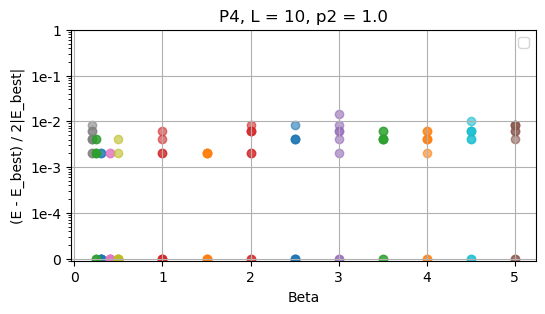

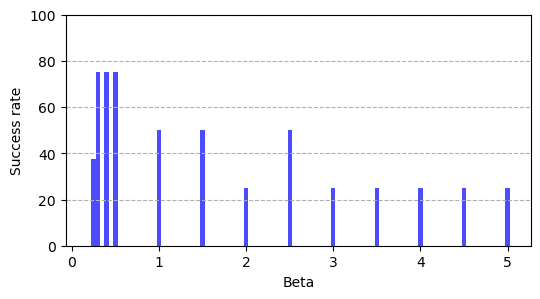

In [538]:
TOPOLOGY = "P4"
L = "10"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}_beta")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_energy_vs_beta(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
# plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{0.25: [-2219.8103168959433, -2233.810316895944, -2219.8103168959433, -2229.810316895943, -2221.8103168959433, -2227.810316895944, -2227.8103168959437, -2233.810316895943], 0.5: [-2205.9244744500306, -2229.8103168959433, -2237.8103168959433, -2237.8103168959433, -2235.8103168959433, -2223.810316895943, -2239.810316895944, -2233.8103168959437], 0.75: [-2217.8103168959433, -2235.8103168959433, -2222.8673956729876, -2231.8103168959433, -2219.810316895943, -2235.8103168959433, -2237.8103168959433, -2225.8103168959437], 1.0: [-2211.810316895943, -2229.810316895944, -2215.8103168959437, -2205.8103168959433, -2215.8103168959433, -2216.8673956729876, -2213.810316895943, -2207.924474450031], 1.5: [-2176.9815532270745, -2138.705298670786, -2225.8103168959433, -2215.8103168959437, -2196.867395672987, -2225.810316895944, -2229.8103168959433, -2205.8673956729867], 2.0: [-2181.924474450031, -2189.810316895943, -2191.810316895944, -2231.810316895944, -2211.8103168959433, -2219.8103168959433, -2213.81

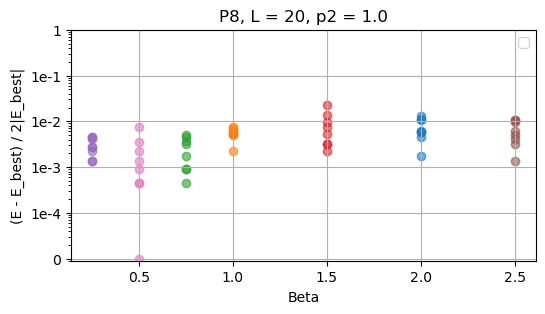

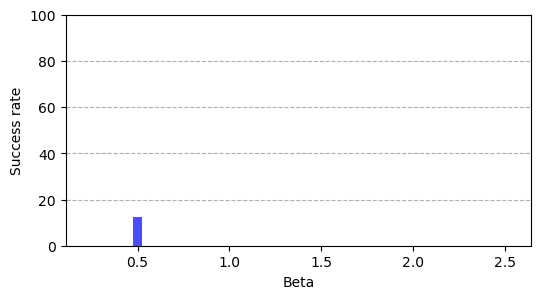

In [540]:
TOPOLOGY = "P8"
L = "20"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_energy_vs_beta(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
# plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)


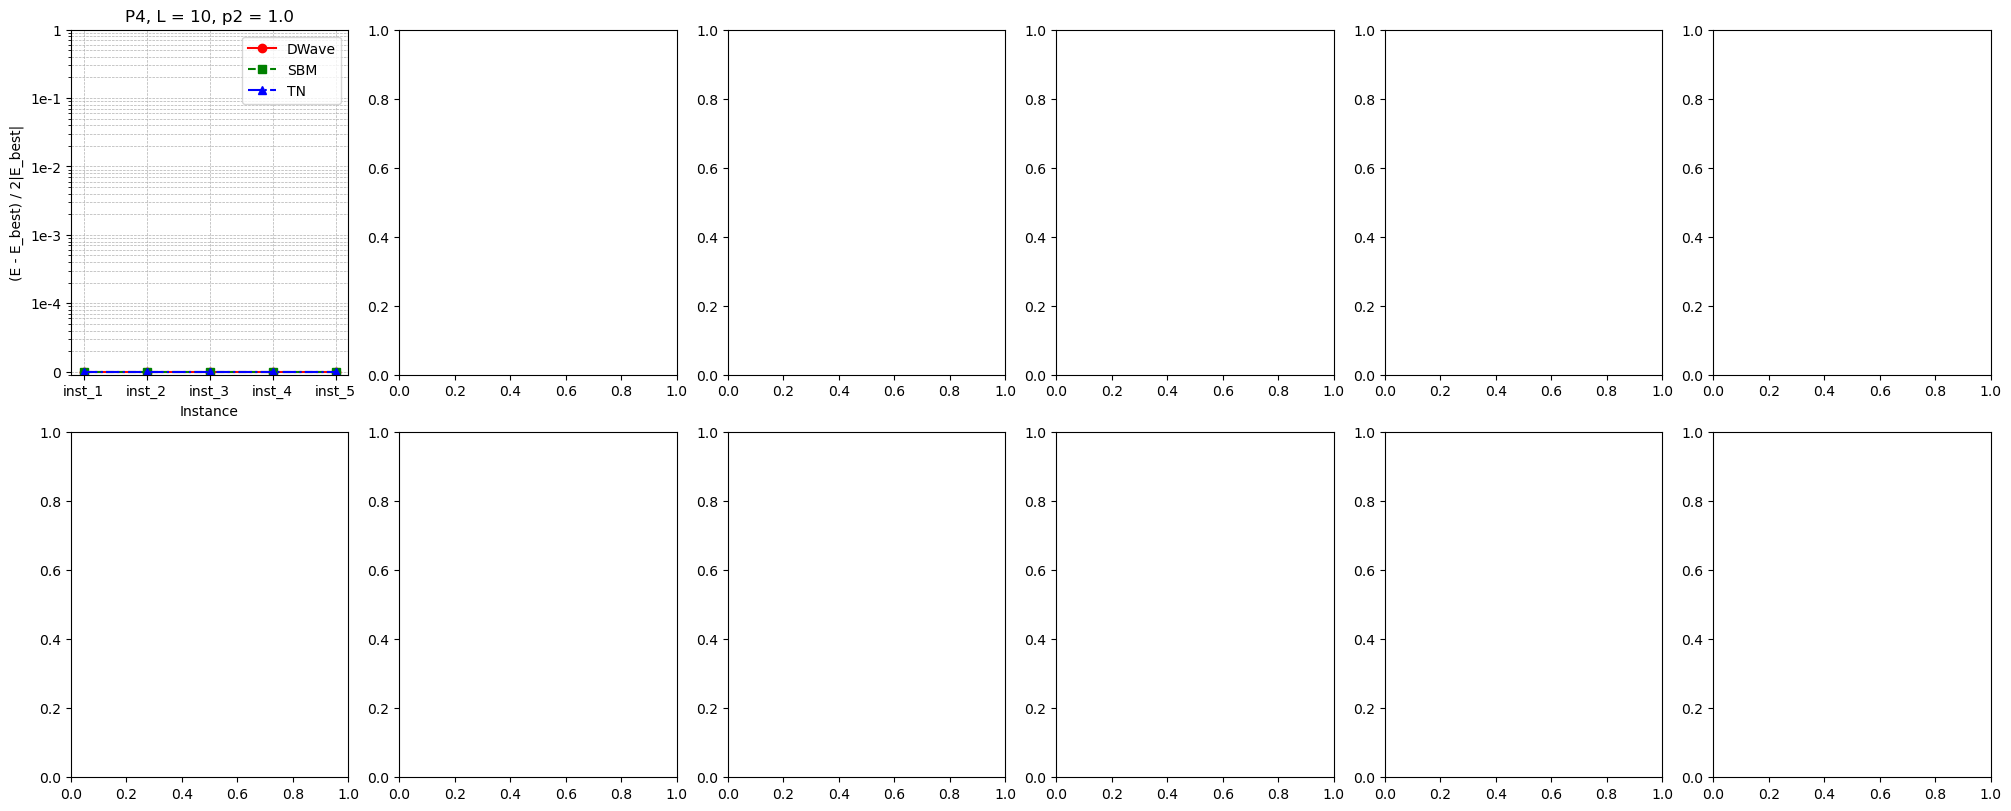

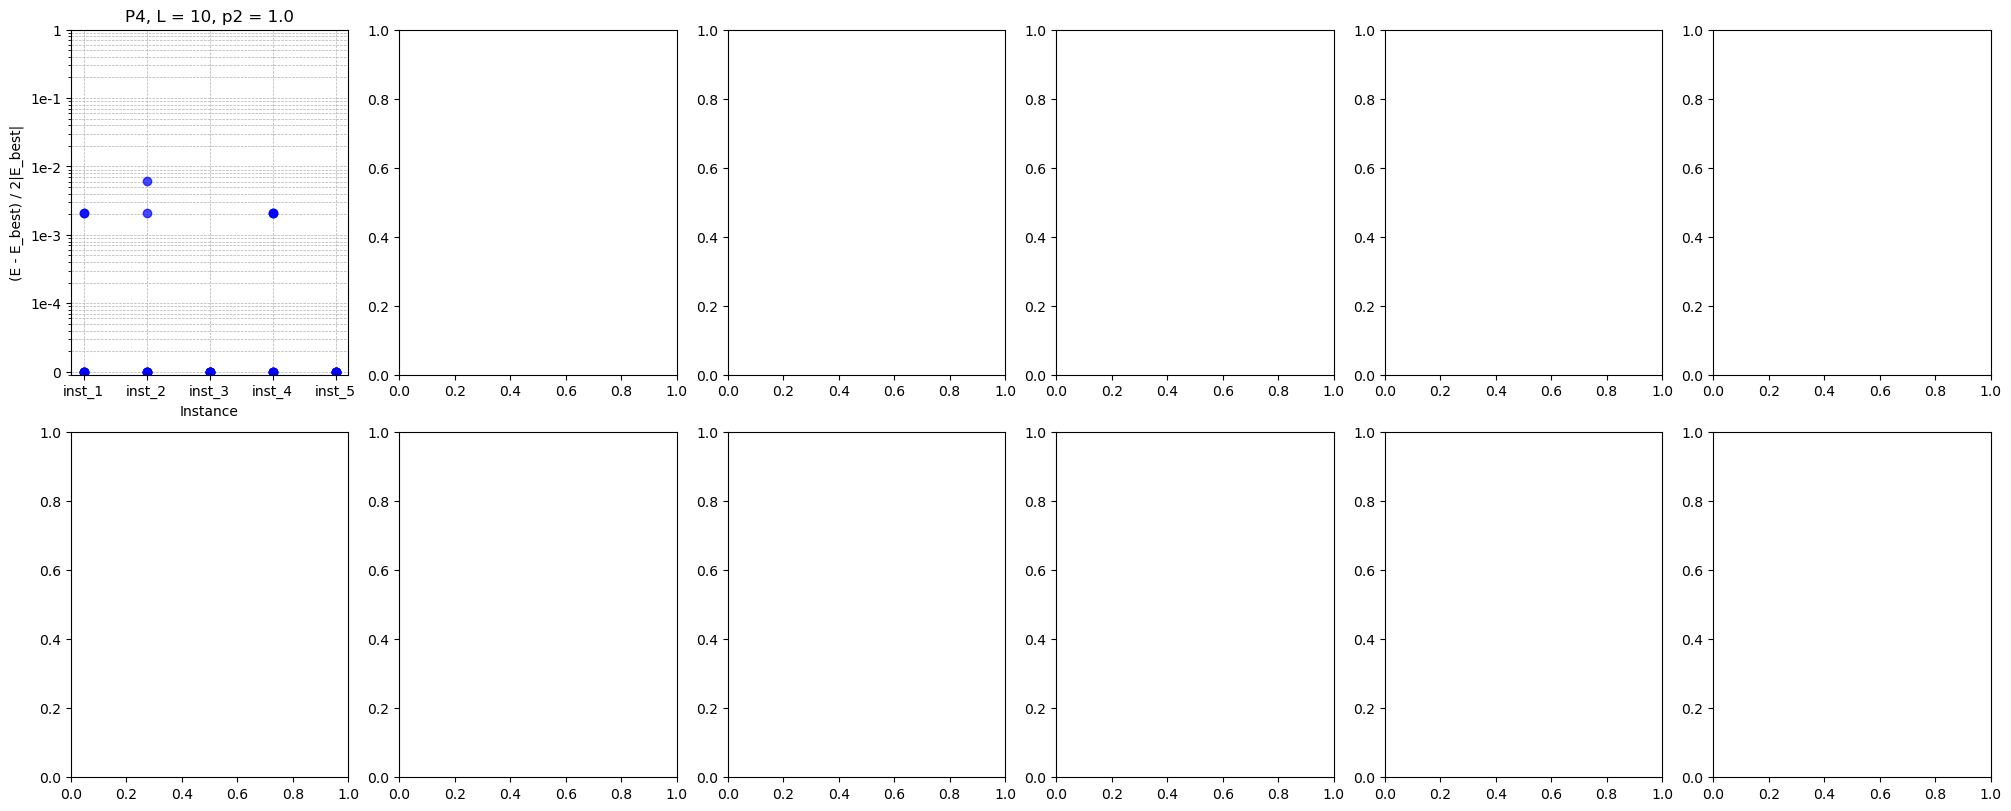

In [542]:
TOPOLOGY = "P4"
L = "10"
root = os.getcwd()
tn_directory = os.path.join(root, "tn_results", f"{TOPOLOGY}_adv6.4_results", "new", f"{TOPOLOGY}_L{L}")
dwave_directory = os.path.join(root, "dwave_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
sbm_directory = os.path.join(root, "sbm_results", f"{TOPOLOGY}_adv6.4_results", f"raw_results_{TOPOLOGY}.csv")
output_csv = os.path.join(root, "best", f"{TOPOLOGY}_adv6.4_results",f"best_{TOPOLOGY}_2D_L_{L}.csv")
plot_instance_energy_all(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
plot_instance_energy_all_tn(tn_directory, dwave_directory, sbm_directory, output_csv, TOPOLOGY, L)
